In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import sys

project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

In [27]:
from src.config import get_path, get_sample_window

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

CLEAN = Path(get_path('cleaned_dir'))
FIG_DIR = get_path('results_data') / 'figures'
RES_DIR = get_path('results_data') / 'tables'
FIG_DIR.mkdir(parents=True, exist_ok=True)
RES_DIR.mkdir(parents=True, exist_ok=True)

cme = pd.read_parquet(get_path('cleaned_cme'))
der = pd.read_parquet(get_path('cleaned_deribit'))
aux = pd.read_parquet(get_path('cleaned_auxiliary'))

funding_path = get_path('funding_diff')
funding = pd.read_parquet(funding_path) if funding_path.exists() else None

print(f"CME:       {len(cme):>10,} rows, {cme['date'].nunique()} days")
print(f"Deribit:   {len(der):>10,} rows, {der['date'].nunique()} days")
print(f"Auxiliary: {len(aux):>10,} rows, {aux['date'].nunique()} days")
if funding is not None:
    print(f"Funding:   {len(funding):>10,} rows, {funding['date'].nunique()} days")

CME:           65,598 rows, 802 days
Deribit:      326,702 rows, 3105 days
Auxiliary:      2,191 rows, 2191 days
Funding:          964 rows, 964 days


#### 1. Cross-Venue Comparison: Daily Option Counts

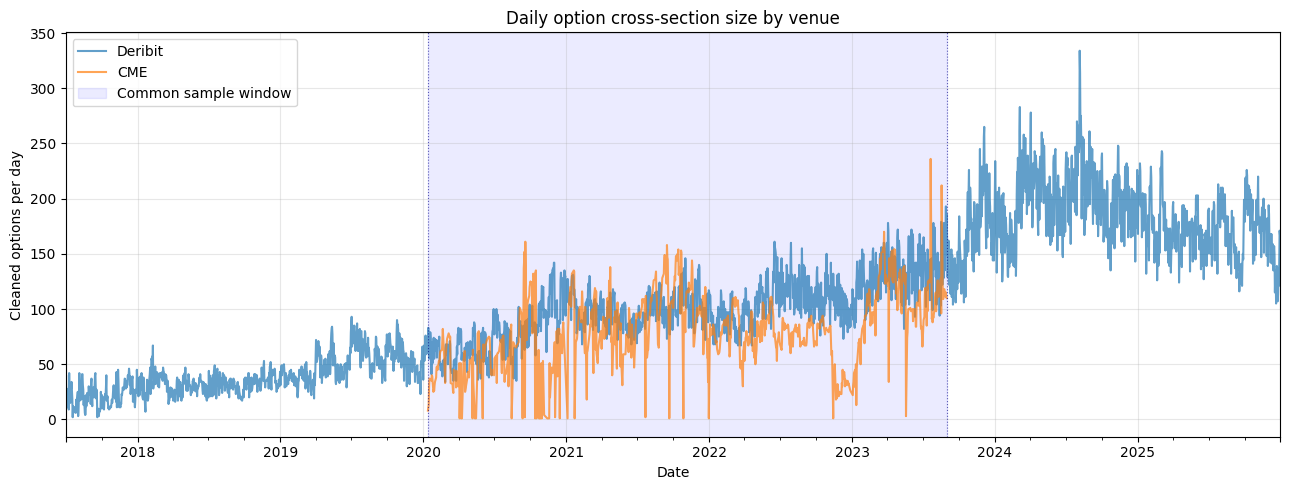

Median per day (full data):
  CME:         82
  Deribit:    100

Median per day (common window only):
  CME:         82
  Deribit:    102


In [18]:
SAMPLE_START = pd.Timestamp('2020-01-13')
SAMPLE_END   = pd.Timestamp('2023-08-31')

daily_cme = cme.groupby('date').size().rename('CME')
daily_der = der.groupby('date').size().rename('Deribit')

fig, ax = plt.subplots(figsize=(13, 5))
daily_der.plot(ax=ax, label='Deribit', alpha=0.7)
daily_cme.plot(ax=ax, label='CME', alpha=0.7)

ax.axvspan(SAMPLE_START, SAMPLE_END, alpha=0.08, color='blue', label='Common sample window')
ax.axvline(SAMPLE_START, color='navy', linestyle=':', linewidth=0.8, alpha=0.6)
ax.axvline(SAMPLE_END, color='navy', linestyle=':', linewidth=0.8, alpha=0.6)

ax.set_ylabel('Cleaned options per day')
ax.set_xlabel('Date')
ax.set_title('Daily option cross-section size by venue')
ax.legend(loc='upper left')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_daily_option_counts.png', dpi=150)
plt.show()

# Full data
print("Median per day (full data):")
print(f"  CME:     {daily_cme.median():>6.0f}")
print(f"  Deribit: {daily_der.median():>6.0f}")

# Common window only
cw_cme = daily_cme[(daily_cme.index >= SAMPLE_START) & (daily_cme.index <= SAMPLE_END)]
cw_der = daily_der[(daily_der.index >= SAMPLE_START) & (daily_der.index <= SAMPLE_END)]
print(f"\nMedian per day (common window only):")
print(f"  CME:     {cw_cme.median():>6.0f}")
print(f"  Deribit: {cw_der.median():>6.0f}")

#### 2. ATM Implied Volatility Time Series

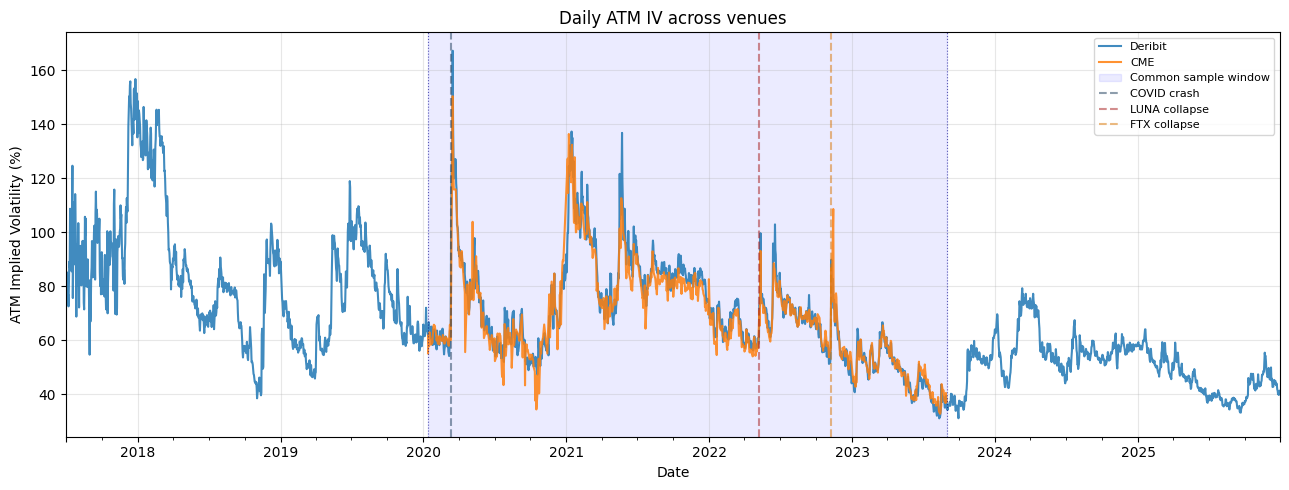

In [19]:
def atm_iv_series(df, venue_label):
    df = df.copy()
    df['abs_kappa'] = df['log_moneyness'].abs()
    idx = df.groupby(['date', 'expiration'])['abs_kappa'].idxmin()
    atm = df.loc[idx]
    return atm.groupby('date')['impliedvolatility'].mean()

atm_cme = atm_iv_series(cme, 'CME')
atm_der = atm_iv_series(der, 'Deribit')

fig, ax = plt.subplots(figsize=(13, 5))
(atm_der * 100).plot(ax=ax, label='Deribit', alpha=0.85)
(atm_cme * 100).plot(ax=ax, label='CME', alpha=0.85)

ax.axvspan(SAMPLE_START, SAMPLE_END, alpha=0.08, color='blue', label='Common sample window')
ax.axvline(SAMPLE_START, color='navy', linestyle=':', linewidth=0.8, alpha=0.6)
ax.axvline(SAMPLE_END, color='navy', linestyle=':', linewidth=0.8, alpha=0.6)

ax.axvline(pd.Timestamp('2020-03-12'), color='#1C3D5A', linestyle='--', alpha=0.5, label='COVID crash')
ax.axvline(pd.Timestamp('2022-05-09'), color='#A61C1C', linestyle='--', alpha=0.5, label='LUNA collapse')
ax.axvline(pd.Timestamp('2022-11-08'), color='#D97706', linestyle='--', alpha=0.5, label='FTX collapse')

ax.set_ylabel('ATM Implied Volatility (%)')
ax.set_xlabel('Date')
ax.set_title('Daily ATM IV across venues')
ax.legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_atm_iv_timeseries.png', dpi=150)
plt.show()

#### 3. Slice Density Diagnostics (Critical for SSVI)

In [20]:
def slice_diagnostics(df, name):
    per_slice = df.groupby(['date', 'expiration']).size().reset_index(name='n')
    print(f"\n=== {name} slice density ===")
    print(per_slice['n'].describe())
    print(f"Slices with < 4 options: {(per_slice['n'] < 4).sum():,} "
          f"({(per_slice['n'] < 4).mean():.1%})")
    print(f"Slices with < 3 options: {(per_slice['n'] < 3).sum():,} "
          f"({(per_slice['n'] < 3).mean():.1%})")
    return per_slice

slices_cme = slice_diagnostics(cme, 'CME')
slices_der = slice_diagnostics(der, 'Deribit')


=== CME slice density ===
count    2804.000000
mean       23.394437
std        17.850788
min         1.000000
25%         9.000000
50%        21.000000
75%        34.000000
max       148.000000
Name: n, dtype: float64
Slices with < 4 options: 353 (12.6%)
Slices with < 3 options: 283 (10.1%)

=== Deribit slice density ===
count    13490.000000
mean        24.218087
std         10.975986
min          1.000000
25%         16.000000
50%         22.000000
75%         30.000000
max         69.000000
Name: n, dtype: float64
Slices with < 4 options: 44 (0.3%)
Slices with < 3 options: 26 (0.2%)


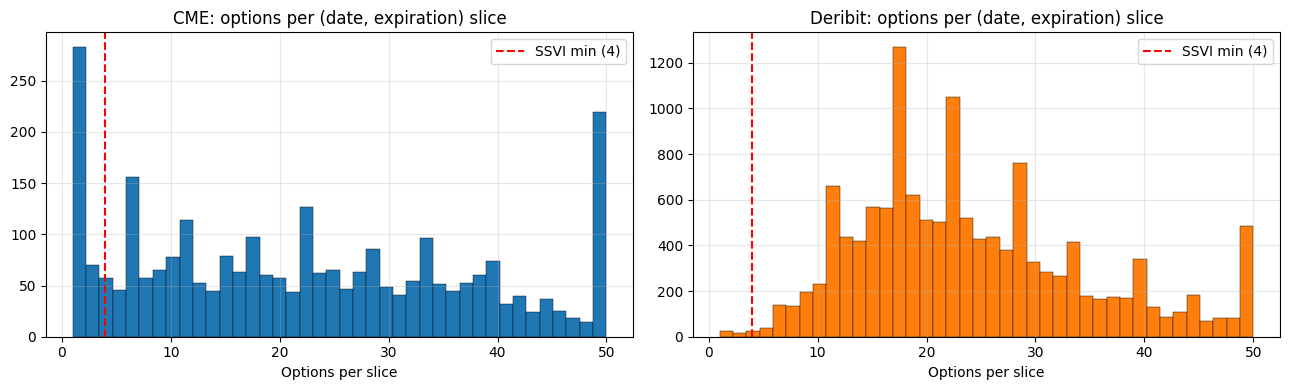

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(slices_cme['n'].clip(upper=50), bins=40, color='C0', edgecolor='black', linewidth=0.3)
axes[0].axvline(4, color='red', linestyle='--', label='SSVI min (4)')
axes[0].set_title('CME: options per (date, expiration) slice')
axes[0].set_xlabel('Options per slice')
axes[0].legend()

axes[1].hist(slices_der['n'].clip(upper=50), bins=40, color='C1', edgecolor='black', linewidth=0.3)
axes[1].axvline(4, color='red', linestyle='--', label='SSVI min (4)')
axes[1].set_title('Deribit: options per (date, expiration) slice')
axes[1].set_xlabel('Options per slice')
axes[1].legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_slice_density.png', dpi=150)
plt.show()

#### 4. Moneyness Coverage by Venue

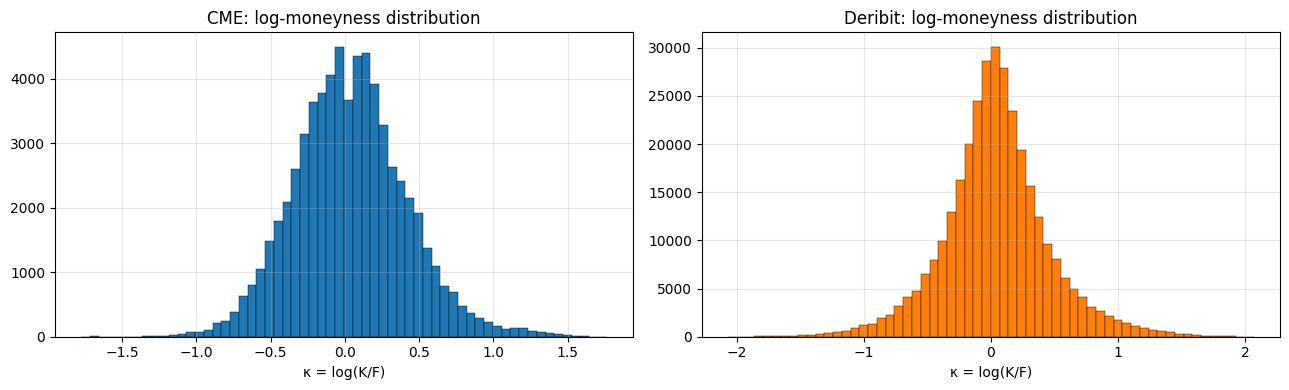

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(cme['log_moneyness'], bins=60, color='C0', edgecolor='black', linewidth=0.3)
axes[0].set_title('CME: log-moneyness distribution')
axes[0].set_xlabel('κ = log(K/F)')

axes[1].hist(der['log_moneyness'], bins=60, color='C1', edgecolor='black', linewidth=0.3)
axes[1].set_title('Deribit: log-moneyness distribution')
axes[1].set_xlabel('κ = log(K/F)')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_moneyness_coverage.png', dpi=150)
plt.show()

#### 5. Auxiliary Panel: Conditioning Variables

In [23]:
print("Auxiliary panel missing-value summary:")
print(aux.isna().sum())
print(f"\nDVOL first valid date: {aux.dropna(subset=['dvol'])['date'].min().date()}")
print(f"DVOL last valid date:  {aux.dropna(subset=['dvol'])['date'].max().date()}")

Auxiliary panel missing-value summary:
date            0
btc_spot        0
rv              0
vix             0
dvol          461
baa_spread      0
dgs2            0
dxy             0
fng             1
dtype: int64

DVOL first valid date: 2021-04-06
DVOL last valid date:  2025-12-30


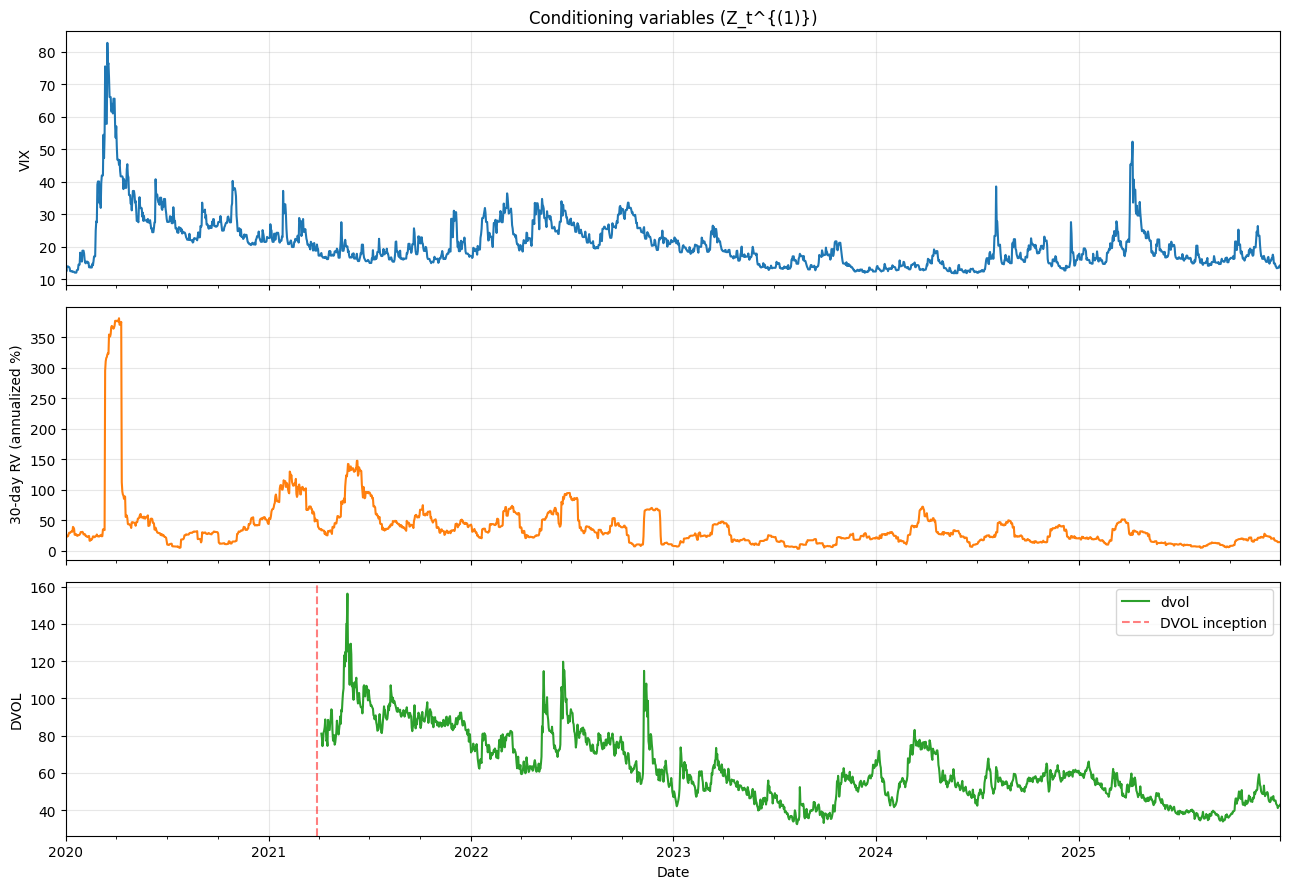

In [24]:
fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)
aux.set_index('date')['vix'].plot(ax=axes[0], color='C0')
axes[0].set_ylabel('VIX')
axes[0].set_title('Conditioning variables (Z_t^{(1)})')

(aux.set_index('date')['rv'] * 100).plot(ax=axes[1], color='C1')
axes[1].set_ylabel('30-day RV (annualized %)')

aux.set_index('date')['dvol'].plot(ax=axes[2], color='C2')
axes[2].set_ylabel('DVOL')
axes[2].set_xlabel('Date')
axes[2].axvline(pd.Timestamp('2021-03-29'), color='red', linestyle='--', alpha=0.5,
                label='DVOL inception')
axes[2].legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_conditioning_variables.png', dpi=150)
plt.show()

#### 6. Funding Rate Differential (HL - DER, Annualized)

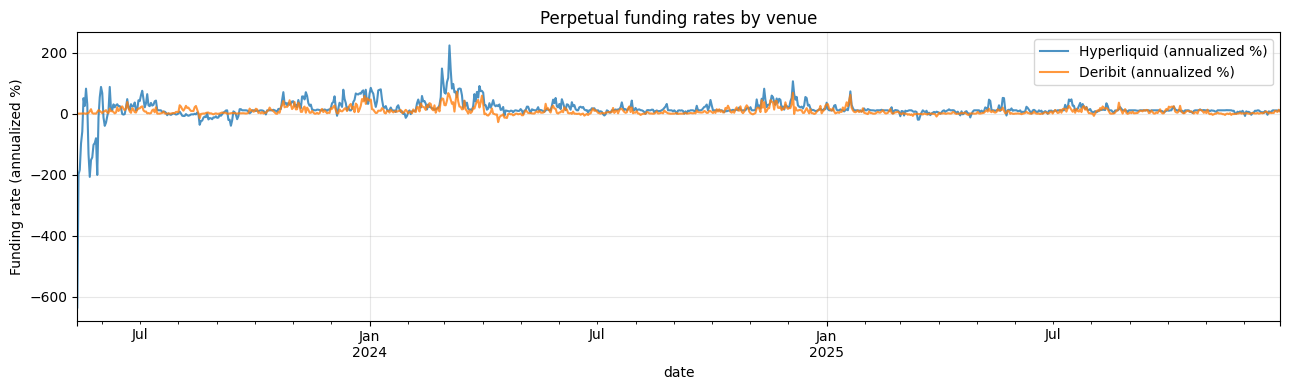

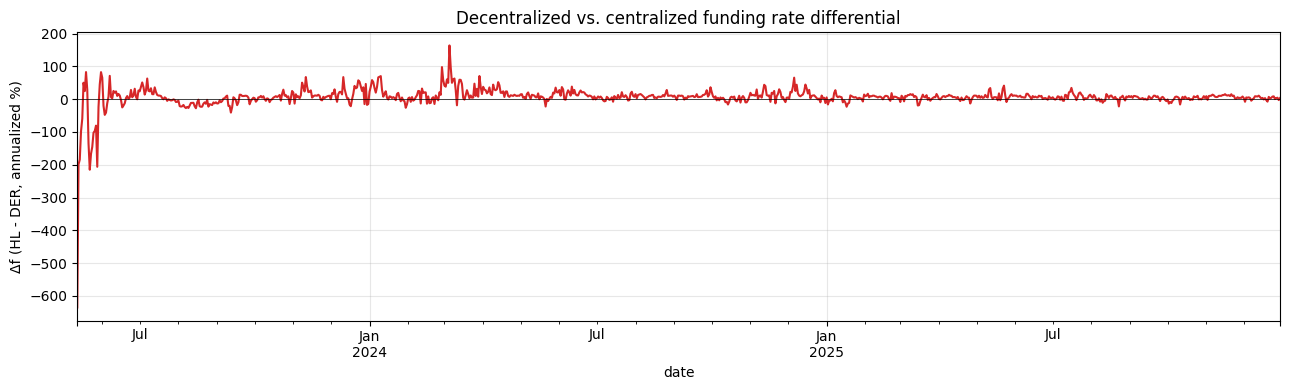


Funding rate statistics (annualized):
       funding_hl_annual  funding_der_annual  delta_f_hl_der
count         964.000000          964.000000      964.000000
mean            0.147445            0.083242        0.064203
std             0.348048            0.114546        0.319186
min            -6.354915           -0.278013       -6.353225
25%             0.084278            0.006842        0.008307
50%             0.109500            0.044849        0.070942
75%             0.208380            0.124771        0.126461
max             2.237398            0.717332        1.640086


In [25]:
if funding is not None:
    fig, ax = plt.subplots(figsize=(13, 4))
    (funding.set_index('date')['funding_hl_annual'] * 100).plot(
        ax=ax, label='Hyperliquid (annualized %)', alpha=0.8)
    (funding.set_index('date')['funding_der_annual'] * 100).plot(
        ax=ax, label='Deribit (annualized %)', alpha=0.8)
    ax.set_ylabel('Funding rate (annualized %)')
    ax.set_title('Perpetual funding rates by venue')
    ax.legend()
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'fig_funding_rates.png', dpi=150)
    plt.show()
    
    fig, ax = plt.subplots(figsize=(13, 4))
    (funding.set_index('date')['delta_f_hl_der'] * 100).plot(ax=ax, color='C3')
    ax.axhline(0, color='black', linewidth=0.5)
    ax.set_ylabel('Δf (HL - DER, annualized %)')
    ax.set_title('Decentralized vs. centralized funding rate differential')
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'fig_funding_differential.png', dpi=150)
    plt.show()
    
    print("\nFunding rate statistics (annualized):")
    print(funding[['funding_hl_annual', 'funding_der_annual', 'delta_f_hl_der']].describe())
else:
    print('Funding panel not yet available — run clean_hyperliquid.py first.')

#### 7. Thesis Data Summary Table

In [29]:
start_str, end_str = get_sample_window()
SAMPLE_START = pd.Timestamp(start_str)
SAMPLE_END = pd.Timestamp(end_str)

der_cw = der[(der['date'] >= SAMPLE_START) & (der['date'] <= SAMPLE_END)]
daily_der_cw = der_cw.groupby('date').size()
slices_der_cw = der_cw.groupby(['date', 'expiration']).size().reset_index(name='n')

summary = pd.DataFrame({
    'CME': [
        len(cme),
        cme['date'].nunique(),
        cme['date'].min().date(),
        cme['date'].max().date(),
        round(daily_cme.median()),
        round(slices_cme['n'].median()),
        (cme['callput']=='C').sum(),
        (cme['callput']=='P').sum(),
    ],
    'Deribit': [
        len(der_cw),
        der_cw['date'].nunique(),
        der_cw['date'].min().date(),
        der_cw['date'].max().date(),
        round(daily_der_cw.median()),
        round(slices_der_cw['n'].median()),
        (der_cw['callput']=='C').sum(),
        (der_cw['callput']=='P').sum(),
    ],
}, index=['Cleaned rows', 'Trading days', 'Sample start', 'Sample end',
         'Median options/day', 'Median options/slice', 'Calls', 'Puts'])

print(summary)
summary.to_csv(RES_DIR / 'data_summary.csv')
print(f"\nNote: Deribit rows scoped to common window ({SAMPLE_START.date()} – {SAMPLE_END.date()})")

                             CME     Deribit
Cleaned rows               65598      135081
Trading days                 802        1327
Sample start          2020-01-13  2020-01-13
Sample end            2023-08-31  2023-08-31
Median options/day            82         102
Median options/slice          21          20
Calls                      34414       74066
Puts                       31184       61015

Note: Deribit rows scoped to common window (2020-01-13 – 2023-08-31)


#### 8. Grid parameters optimization

In [30]:
start_str, end_str = get_sample_window()
venue_map = [('CME', get_path('cleaned_cme')), ('Deribit', get_path('cleaned_deribit'))]

for venue, path in venue_map:
    df = pd.read_parquet(path)
    
    # Trim Deribit to CME window
    df = df[(df['date'] >= start_str) & (df['date'] <= end_str)]
    
    print(f"\n{'='*60}")
    print(f"  {venue} Summary Statistics")
    print(f"{'='*60}")
    
    # DTE distribution
    print(f"\n  Days to expiry:")
    print(f"  {df['days_to_expiry'].describe().to_string()}")
    
    # Unique DTE values (what maturities actually exist?)
    dte_counts = df.groupby('days_to_expiry').size()
    print(f"\n  Most common DTEs (top 15):")
    print(f"  {dte_counts.nlargest(15).to_string()}")
    
    # Log-moneyness distribution
    print(f"\n  Log-moneyness (κ):")
    print(f"  {df['log_moneyness'].describe().to_string()}")
    
    # κ percentiles
    for p in [1, 5, 25, 50, 75, 95, 99]:
        print(f"    p{p}: {df['log_moneyness'].quantile(p/100):.4f}")
    
    # τ (in years) distribution
    print(f"\n  τ (years):")
    print(f"  {df['tau'].describe().to_string()}")
    
    # How many expirations per day?
    exp_per_day = df.groupby('date')['expiration'].nunique()
    print(f"\n  Expirations per day: median={exp_per_day.median():.0f}, "
          f"min={exp_per_day.min()}, max={exp_per_day.max()}")
    
    # IV distribution
    print(f"\n  Implied Volatility:")
    print(f"  {df['impliedvolatility'].describe().to_string()}")


  CME Summary Statistics

  Days to expiry:
  count    65598.000000
mean        50.016052
std         34.181982
min         10.000000
25%         25.000000
50%         41.000000
75%         67.000000
max        180.000000

  Most common DTEs (top 15):
  days_to_expiry
19    1709
18    1708
21    1650
25    1614
27    1551
26    1532
12    1450
20    1424
10    1423
11    1415
28    1391
13    1371
24    1336
32    1332
34    1330

  Log-moneyness (κ):
  count    65598.000000
mean         0.037603
std          0.379596
min         -1.774611
25%         -0.214765
50%          0.029816
75%          0.266741
max          1.762756
    p1: -0.8098
    p5: -0.5578
    p25: -0.2148
    p50: 0.0298
    p75: 0.2667
    p95: 0.6704
    p99: 1.0711

  τ (years):
  count    65598.000000
mean         0.136936
std          0.093585
min          0.027379
25%          0.068446
50%          0.112252
75%          0.183436
max          0.492813

  Expirations per day: median=3, min=1, max=7

  Implied Vo